In [2]:
!pip install xlrd

  Using cached xlrd-2.0.2-py2.py3-none-any.whl.metadata (3.5 kB)
Using cached xlrd-2.0.2-py2.py3-none-any.whl (96 kB)


In [3]:
import os
import pandas as pd

# Paths
folder1 = "/home/sahil/Desktop/Rl_Project_Final/data/Metadata"
folder2 = "/home/sahil/Desktop/Rl_Project_Final/data/metadata_xls"
output_folder = "/home/sahil/Desktop/Rl_Project_Final/data/Metacsv"

# Create output folder if not exists
os.makedirs(output_folder, exist_ok=True)

# Function to convert excel to csv
def convert_folder_to_csv(folder_path):
    data_dict = {}
    
    for file in os.listdir(folder_path):
        if file.endswith(".xls") or file.endswith(".xlsx"):
            file_path = os.path.join(folder_path, file)
            
            try:
                df = pd.read_excel(file_path)
                
                csv_name = os.path.splitext(file)[0] + ".csv"
                csv_path = os.path.join(output_folder, csv_name)
                
                df.to_csv(csv_path, index=False)
                print(f"✅ Converted: {file} → {csv_name}")
                
                data_dict[file] = df
                
            except Exception as e:
                print(f"❌ Error in {file}: {e}")
    
    return data_dict

print("\n--- Converting Folder 1 ---")
data1 = convert_folder_to_csv(folder1)

print("\n--- Converting Folder 2 ---")
data2 = convert_folder_to_csv(folder2)

# 🔍 Compare files
print("\n--- Comparing Data ---")

common_files = set(data1.keys()).intersection(set(data2.keys()))

for file in common_files:
    try:
        same = data1[file].equals(data2[file])
        print(f"{file}: {'✅ SAME' if same else '❌ DIFFERENT'}")
    except:
        print(f"{file}: ⚠️ Could not compare")

# Check if both folders have same filenames
if set(data1.keys()) == set(data2.keys()):
    print("\n📁 Both folders contain SAME file names")
else:
    print("\n📁 Folders have DIFFERENT file sets")


--- Converting Folder 1 ---
✅ Converted: participant_questionnaire.xls → participant_questionnaire.csv
✅ Converted: video_list_fixed.xlsx → video_list_fixed.csv
✅ Converted: participant_ratings.xls → participant_ratings.csv
✅ Converted: online_ratings.xls → online_ratings.csv
✅ Converted: video_list.xlsx → video_list.csv

--- Converting Folder 2 ---
✅ Converted: participant_questionnaire.xls → participant_questionnaire.csv
✅ Converted: participant_ratings.xls → participant_ratings.csv
✅ Converted: online_ratings.xls → online_ratings.csv
✅ Converted: video_list.xls → video_list.csv

--- Comparing Data ---
participant_ratings.xls: ✅ SAME
online_ratings.xls: ✅ SAME
participant_questionnaire.xls: ✅ SAME

📁 Folders have DIFFERENT file sets


In [4]:
import os
import pandas as pd

csv_folder = "/home/sahil/Desktop/Rl_Project_Final/data/Metacsv"

print(f"\n📂 Reading CSV files from: {csv_folder}\n")

for file in os.listdir(csv_folder):
    if file.endswith(".csv"):
        file_path = os.path.join(csv_folder, file)

        try:
            df = pd.read_csv(file_path)

            print(f"\n📄 File: {file}")
            print("-" * 60)
            print("Shape:", df.shape)
            print("Columns:", list(df.columns))
            print(df.head())   # 👈 first 5 rows

        except Exception as e:
            print(f"❌ Error in {file}: {e}")

print("\n🎯 DONE")


📂 Reading CSV files from: /home/sahil/Desktop/Rl_Project_Final/data/Metacsv


📄 File: video_list.csv
------------------------------------------------------------
Shape: (120, 25)
Columns: ['Online_id', 'Experiment_id', 'Lastfm_tag', 'Artist', 'Title', 'Youtube_link', 'Highlight_start', 'Num_ratings', 'VAQ_Estimate', 'VAQ_Online', 'AVG_Valence', 'STD_Valence', 'Q1_Valence', 'Q2_Valence', 'Q3_Valence', 'AVG_Arousal', 'STD_Arousal', 'Q1_Arousal', 'Q2_Arousal', 'Q3_Arousal', 'AVG_Dominance', 'STD_Dominance', 'Q1_Dominance', 'Q2_Dominance', 'Q3_Dominance']
   Online_id  Experiment_id Lastfm_tag            Artist  \
0          1            NaN      happy         Alphabeat   
1          2            1.0        fun  Emilíana Torrini   
2          3            NaN        fun      The Go! Team   
3          4            NaN        fun     Junior Senior   
4          5            NaN        fun       Of Montreal   

                                       Title  \
0                               

In [5]:
import pandas as pd

# ==============================
# 📌 LOAD FILES
# ==============================
video_path = "/home/sahil/Desktop/Rl_Project_Final/data/Metacsv/video_list_fixed.csv"
ratings_path = "/home/sahil/Desktop/Rl_Project_Final/data/Metacsv/participant_ratings.csv"

video_df = pd.read_csv(video_path)
ratings_df = pd.read_csv(ratings_path)

# ==============================
# 🧹 CLEAN DATA
# ==============================

# Remove NaN Experiment_id from video list
video_df = video_df.dropna(subset=["Experiment_id"])

# Convert to int for safe join
video_df["Experiment_id"] = video_df["Experiment_id"].astype(int)
ratings_df["Experiment_id"] = ratings_df["Experiment_id"].astype(int)

# ==============================
# 📊 AGGREGATE RATINGS
# ==============================
# Average Valence & Arousal per Experiment_id

ratings_agg = (
    ratings_df
    .groupby("Experiment_id")[["Valence", "Arousal"]]
    .mean()
    .reset_index()
)

# ==============================
# 🔗 MERGE DATA
# ==============================
final_df = pd.merge(
    video_df[["Experiment_id", "Lastfm_tag"]],
    ratings_agg,
    on="Experiment_id",
    how="inner"
)

# Rename column
final_df.rename(columns={"Lastfm_tag": "Emotion"}, inplace=True)

# ==============================
# 📌 RESULT
# ==============================
print("✅ Final DataFrame:")
print(final_df.head())

print("\nShape:", final_df.shape)

✅ Final DataFrame:
   Experiment_id   Emotion   Valence   Arousal
0              1       fun  6.769063  5.707500
1              2  exciting  6.407813  6.323125
2             11     happy  7.406562  5.342187
3              3       joy  7.532500  6.185313
4             12  cheerful  6.311562  4.040938

Shape: (40, 4)


In [6]:
import pandas as pd

# ==============================
# 📌 LOAD FINAL MERGED DATA
# ==============================
video_path = "/home/sahil/Desktop/Rl_Project_Final/data/Metacsv/video_list_fixed.csv"
ratings_path = "/home/sahil/Desktop/Rl_Project_Final/data/Metacsv/participant_ratings.csv"

video_df = pd.read_csv(video_path)
ratings_df = pd.read_csv(ratings_path)

# ==============================
# 🧹 CLEAN
# ==============================
video_df = video_df.dropna(subset=["Experiment_id"])
video_df["Experiment_id"] = video_df["Experiment_id"].astype(int)
ratings_df["Experiment_id"] = ratings_df["Experiment_id"].astype(int)

# ==============================
# 📊 STEP 1: AVG per Experiment
# ==============================
ratings_agg = (
    ratings_df
    .groupby("Experiment_id")[["Valence", "Arousal"]]
    .mean()
    .reset_index()
)

# ==============================
# 🔗 STEP 2: MERGE WITH EMOTION
# ==============================
merged_df = pd.merge(
    video_df[["Experiment_id", "Lastfm_tag"]],
    ratings_agg,
    on="Experiment_id",
    how="inner"
)

merged_df.rename(columns={"Lastfm_tag": "Emotion"}, inplace=True)

# ==============================
# 📊 STEP 3: AVG per Emotion
# ==============================
emotion_avg = (
    merged_df
    .groupby("Emotion")[["Valence", "Arousal"]]
    .mean()
    .reset_index()
)

# ==============================
# 💾 SAVE CSV
# ==============================
output_path = "/home/sahil/Desktop/Rl_Project_Final/data/Metacsv/emotion_summary.csv"
emotion_avg.to_csv(output_path, index=False)

# ==============================
# 📌 OUTPUT
# ==============================
print("✅ Emotion-wise Average:")
print(emotion_avg)

print(f"\n💾 Saved at: {output_path}")

✅ Emotion-wise Average:
        Emotion   Valence   Arousal
0      cheerful  6.311562  4.040938
1    depressing  4.498437  4.501250
2      exciting  6.407813  6.323125
3           fun  6.769063  5.707500
4         happy  7.368750  5.330781
5          hate  3.969375  5.272500
6           joy  7.532500  6.185313
7          love  6.677812  4.468750
8        lovely  6.150938  3.925312
9    melancholy  3.111562  4.294688
10       mellow  4.994063  3.446563
11          sad  4.049688  4.958125
12  sentimental  4.880937  3.737656
13        shock  3.897813  6.629375
14     terrible  3.816875  5.548750

💾 Saved at: /home/sahil/Desktop/Rl_Project_Final/data/Metacsv/emotion_summary.csv


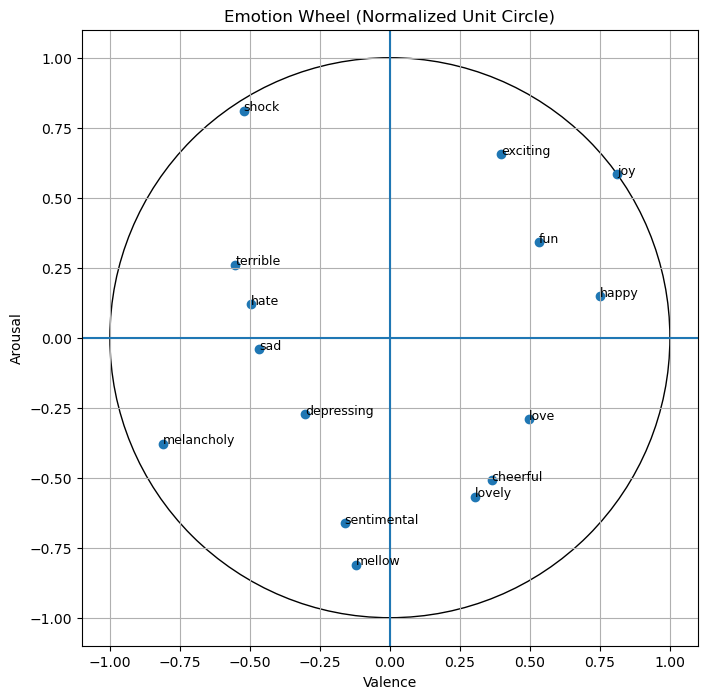

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 📌 LOAD DATA
# ==============================
path = "/home/sahil/Desktop/Rl_Project_Final/data/Metacsv/emotion_summary.csv"
df = pd.read_csv(path)

# ==============================
# 🧹 NORMALIZE TO [-1, 1]
# ==============================

def normalize(col):
    return 2 * (col - col.min()) / (col.max() - col.min()) - 1

df["Valence_norm"] = normalize(df["Valence"])
df["Arousal_norm"] = normalize(df["Arousal"])

# ==============================
# 🔵 SCALE TO UNIT CIRCLE
# ==============================
r = np.sqrt(df["Valence_norm"]**2 + df["Arousal_norm"]**2)
max_r = r.max()

df["Valence_unit"] = df["Valence_norm"] / max_r
df["Arousal_unit"] = df["Arousal_norm"] / max_r

# ==============================
# 🎨 PLOT
# ==============================
plt.figure(figsize=(8,8))

# Draw unit circle
circle = plt.Circle((0, 0), 1, fill=False)
plt.gca().add_patch(circle)

# Scatter points
plt.scatter(df["Valence_unit"], df["Arousal_unit"])

# Annotate emotions
for i in range(len(df)):
    plt.text(
        df["Valence_unit"][i],
        df["Arousal_unit"][i],
        df["Emotion"][i],
        fontsize=9
    )

# Axes
plt.axhline(0)
plt.axvline(0)

plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.xlabel("Valence")
plt.ylabel("Arousal")
plt.title("Emotion Wheel (Normalized Unit Circle)")

plt.grid()
plt.gca().set_aspect('equal', adjustable='box')

plt.show()

In [8]:
def normalize_va(v, a):
    v_norm = 2 * (v - 1) / (9 - 1) - 1
    a_norm = 2 * (a - 1) / (9 - 1) - 1
    return v_norm, a_norm

In [9]:
import pickle
import os

folder_path = "/home/sahil/Desktop/Rl_Project_Final/data/data_preprocessed_python"

# Example: load one file
file_path = os.path.join(folder_path, "s01.dat")

with open(file_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print(type(data))

<class 'dict'>
